Memuat data utama dari: D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_Fill.xlsx
Data utama dimuat: 22392 baris.

Kolom yang tersedia untuk visualisasi (prioritaskan numerik/encoded):
 - Message (Numerik, Unik: 22392)
 - NR_Scan_NR_ARFCN (Numerik, Unik: 3)
 - NR_Scan_PCI_SortedBy_RSRP_0 (Numerik, Unik: 15)
 - NR_Scan_PCI_SortedBy_RSRP_1 (Numerik, Unik: 16)
 - NR_Scan_PCI_SortedBy_RSRP_2 (Numerik, Unik: 16)
 - NR_Scan_PCI_SortedBy_RSRP_3 (Numerik, Unik: 12)
 - NR_Scan_PCI_SortedBy_RSRP_4 (Numerik, Unik: 9)
 - NR_Scan_PCI_SortedBy_RSRP_5 (Numerik, Unik: 9)
 - NR_Scan_PCI_SortedBy_RSRP_6 (Numerik, Unik: 3)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_0 (Numerik, Unik: 15582)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_1 (Numerik, Unik: 15990)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_2 (Numerik, Unik: 16981)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_3 (Numerik, Unik: 14934)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_4 (Numerik, Unik: 14342)
 - NR_Scan_SSB_RSRP_SortedBy_RSRP_5 (Numerik, Unik: 13364)
 - NR_Scan_SSB_RSRP_S

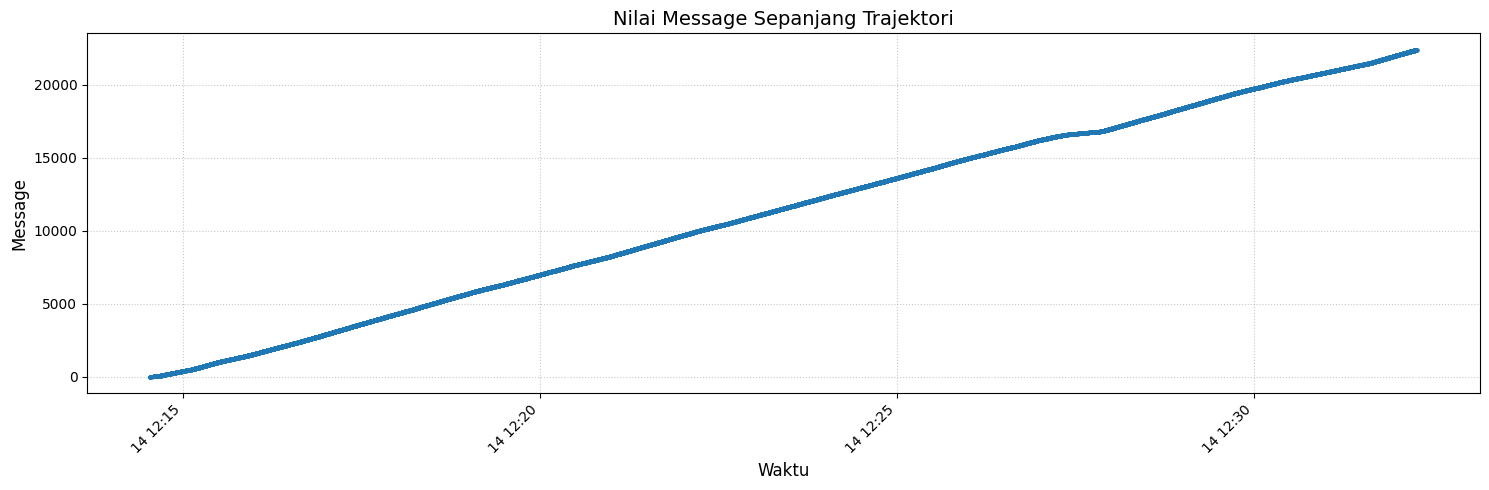

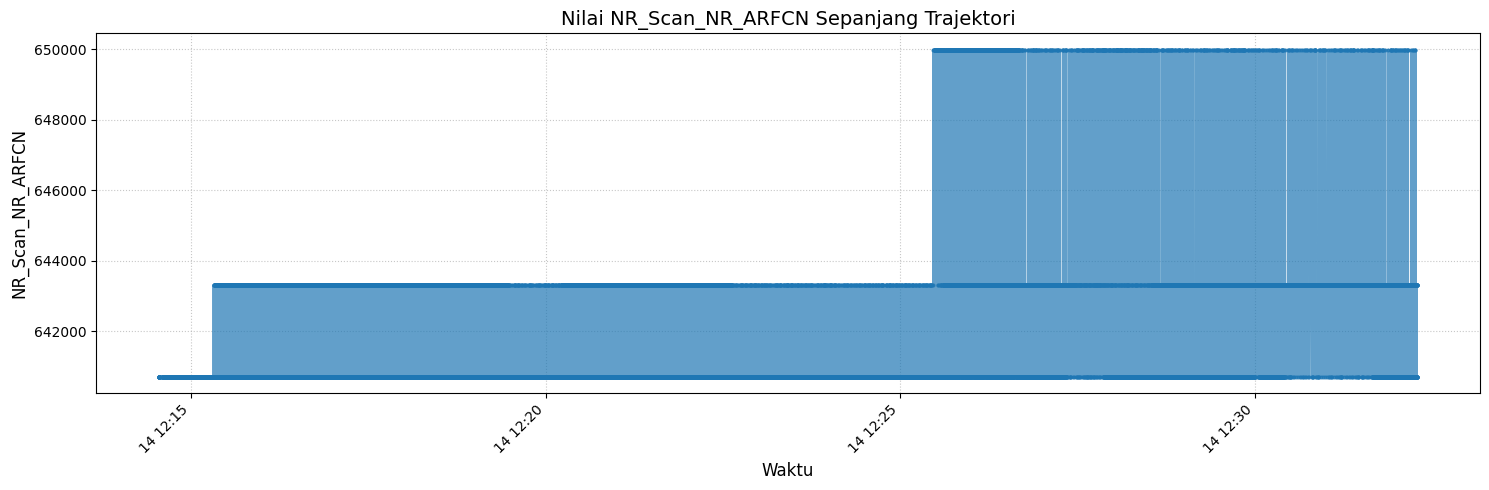

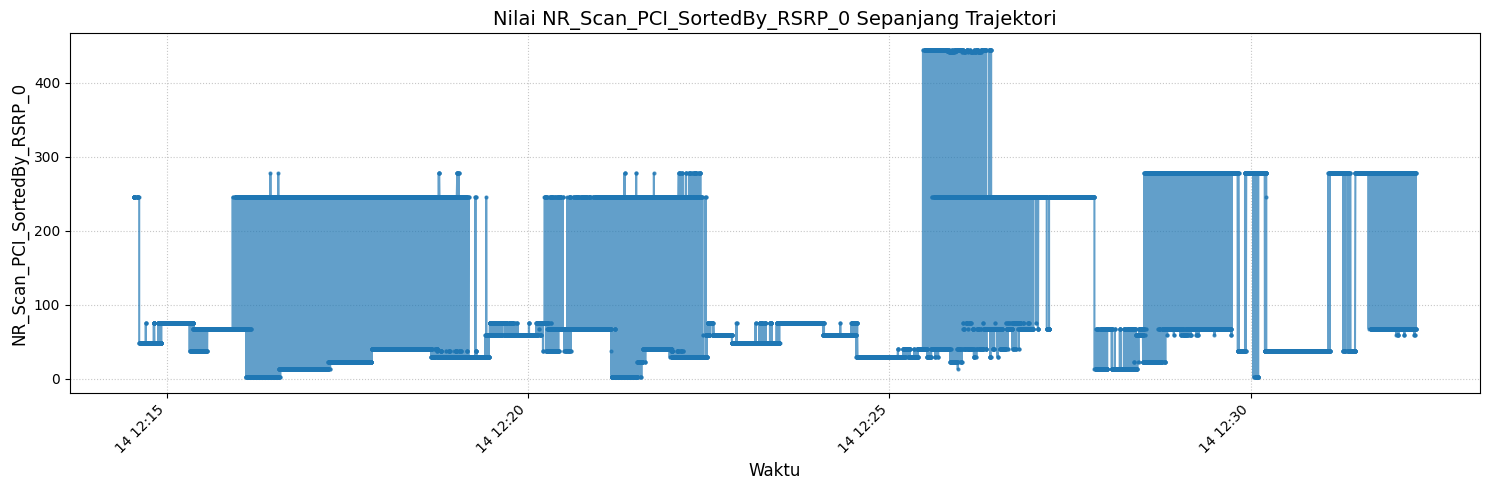

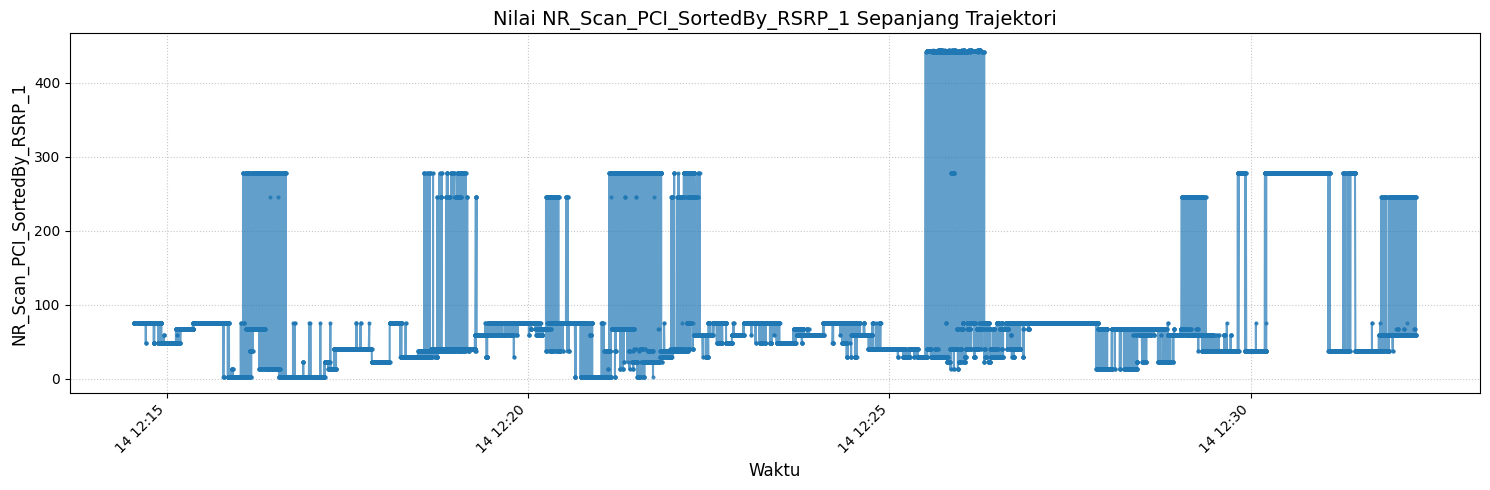

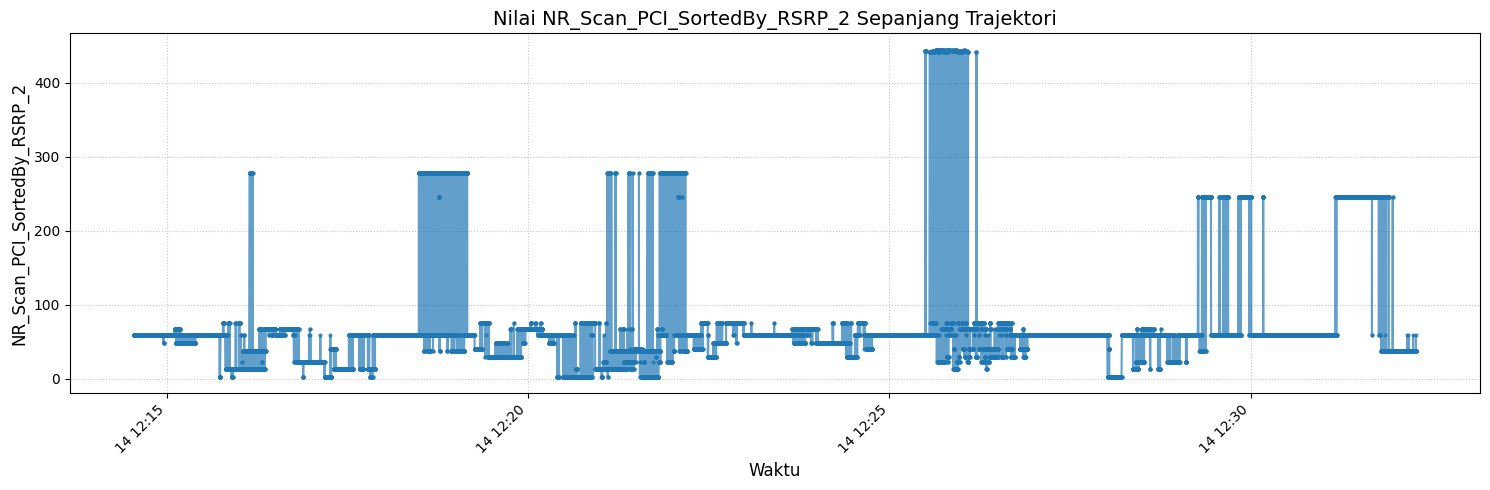

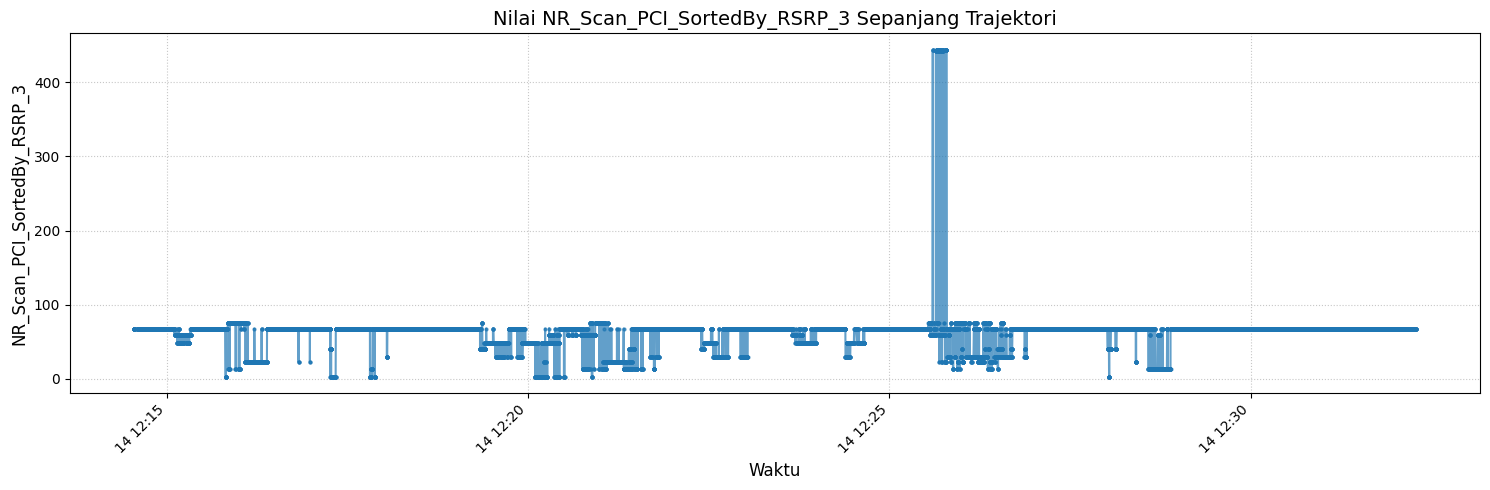

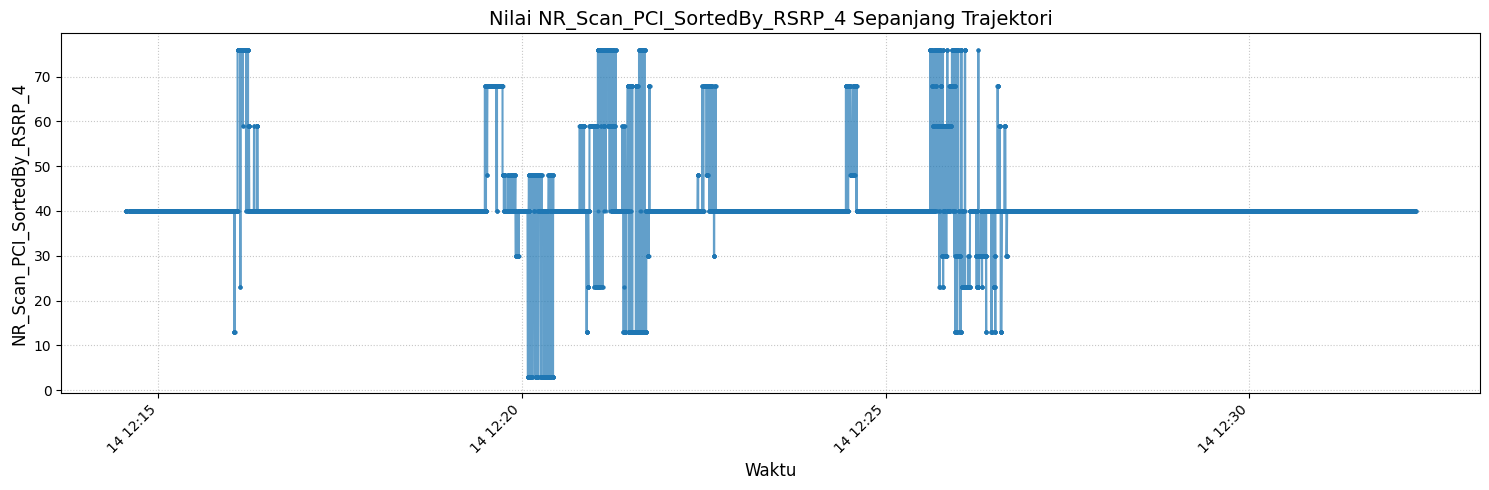

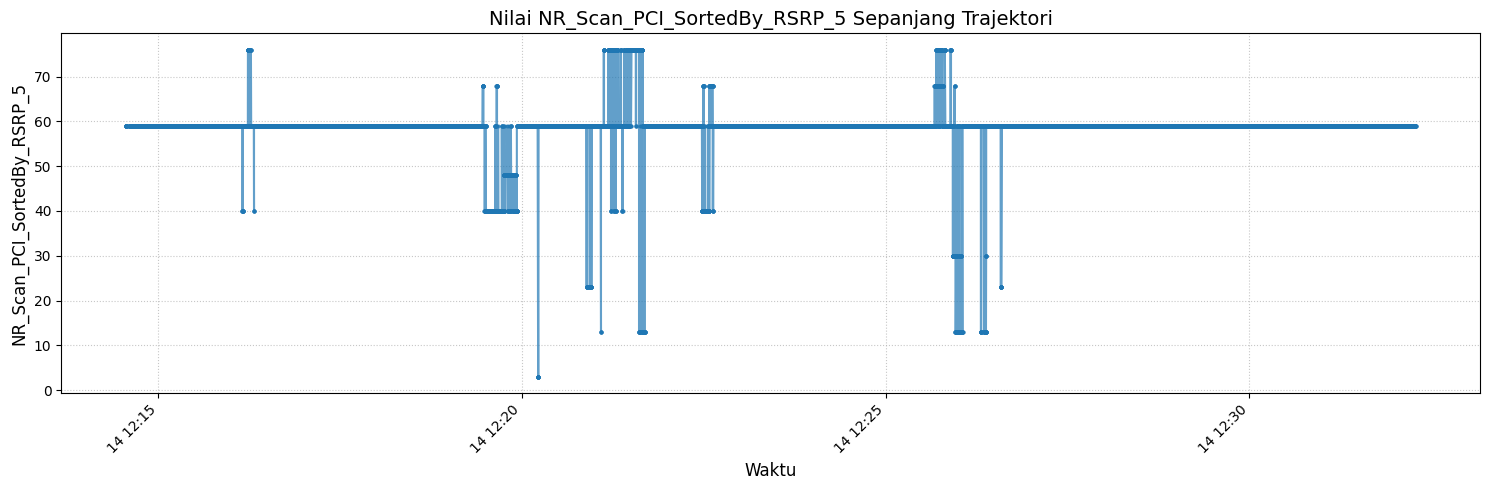

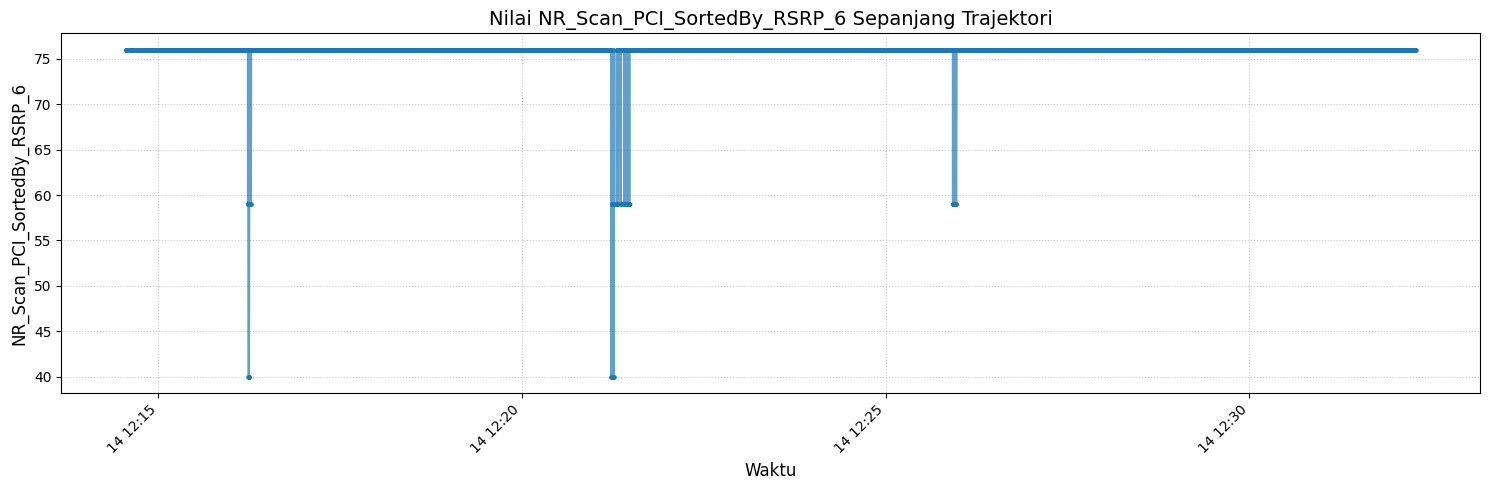

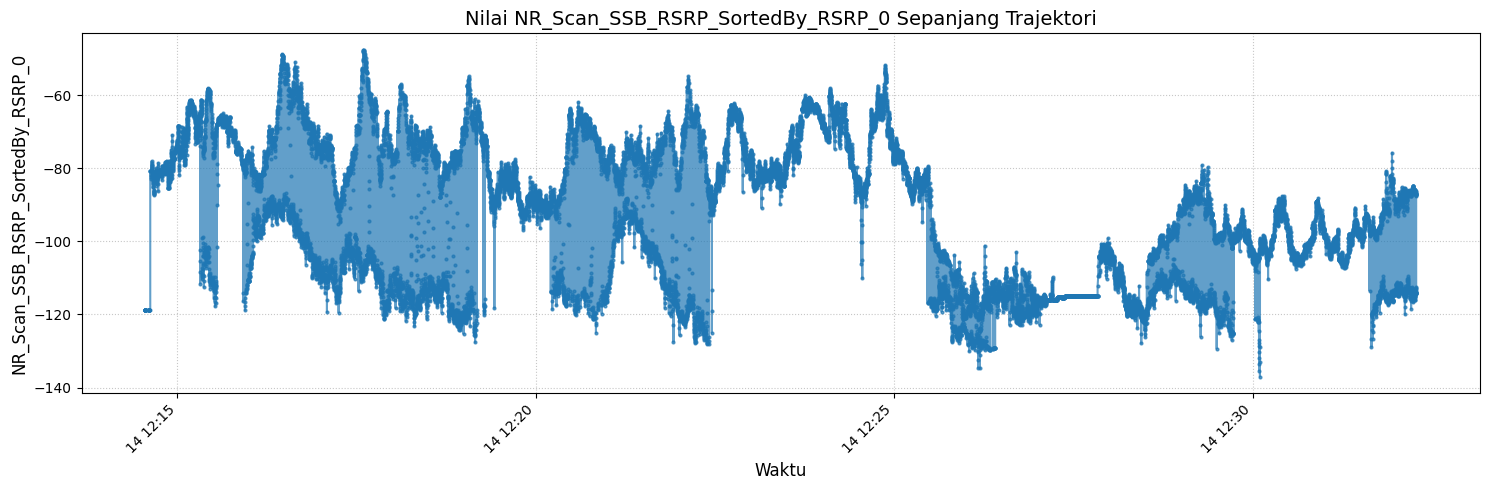

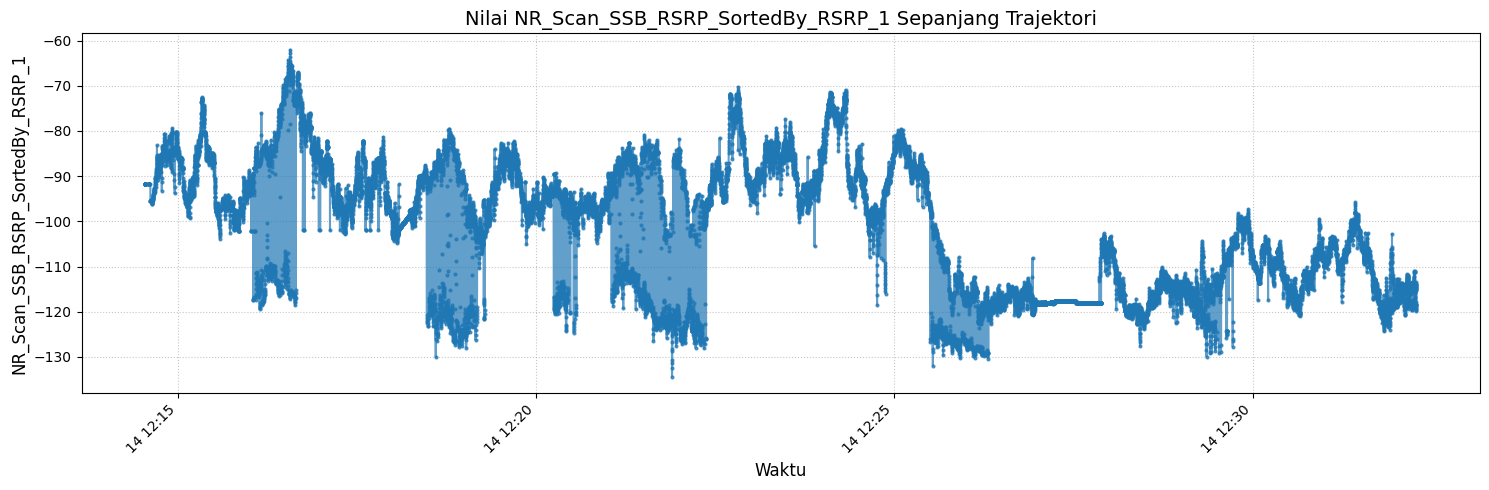

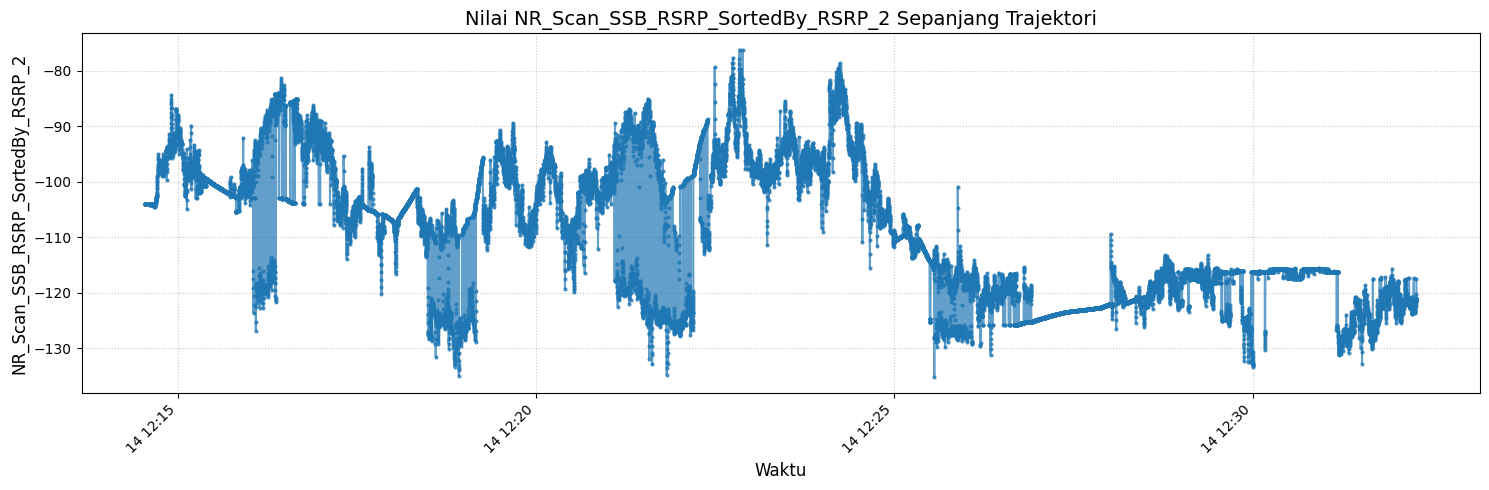

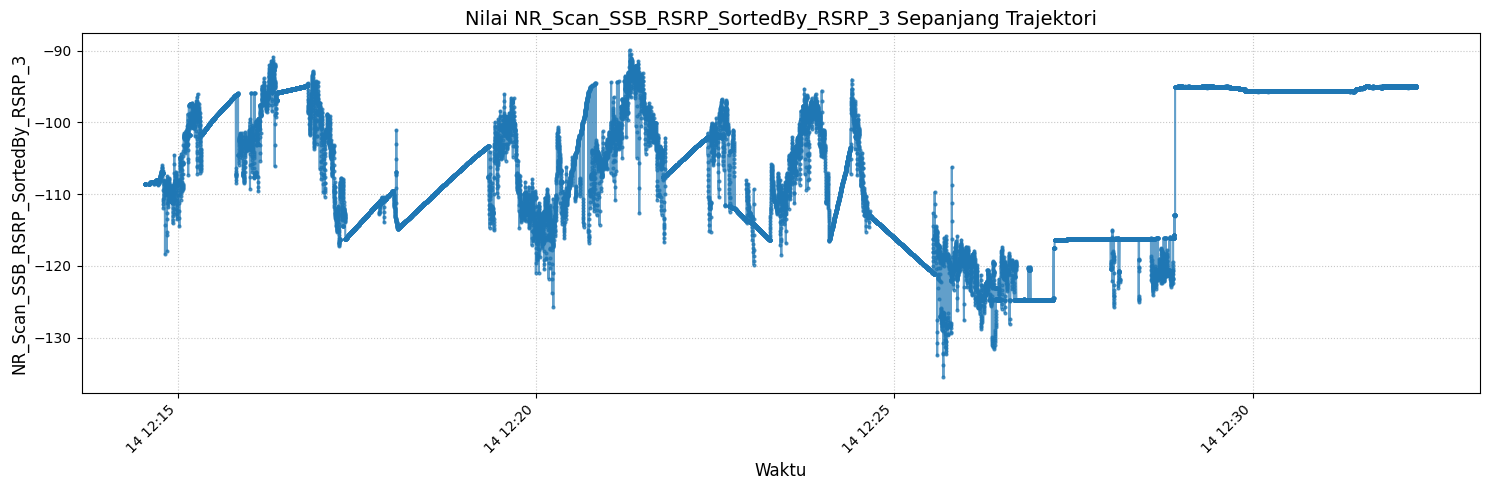

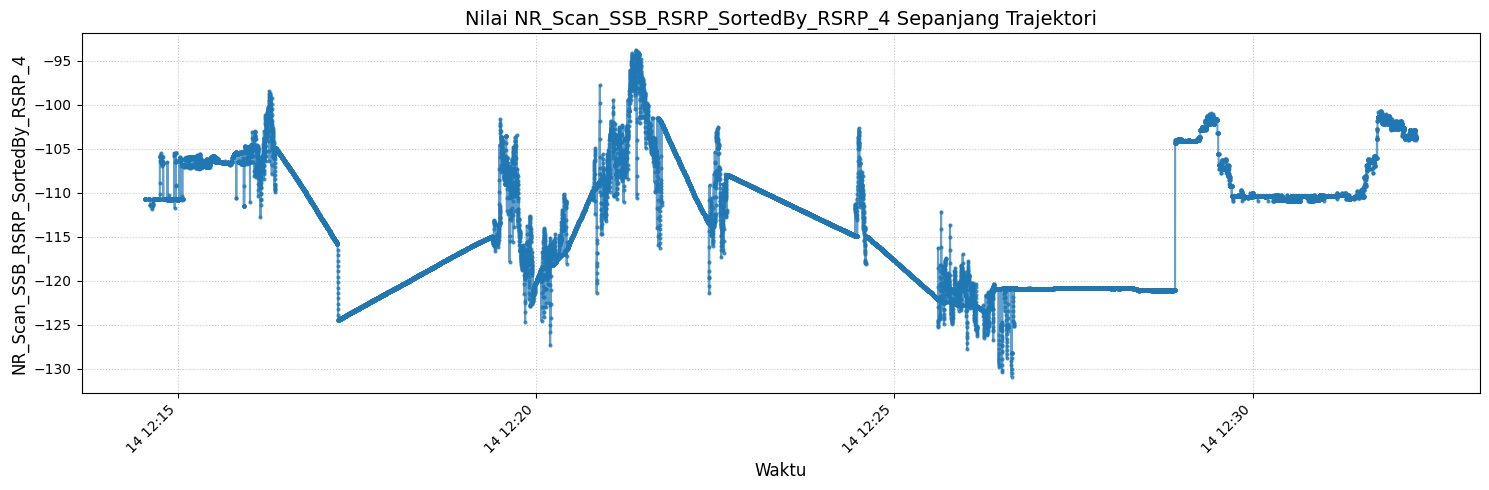

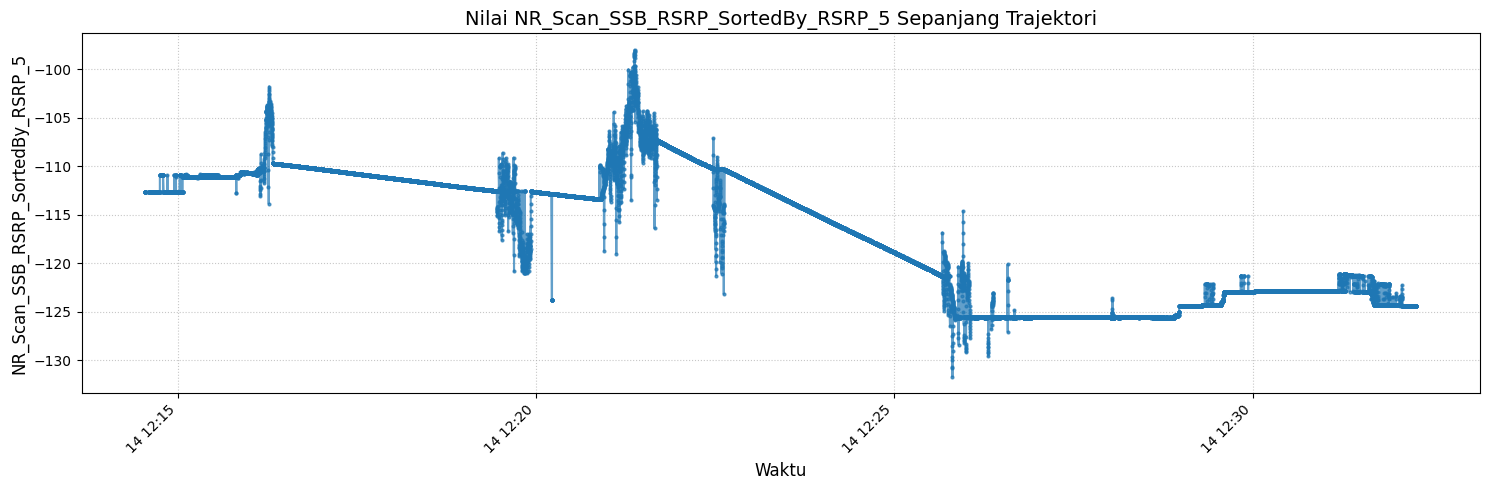

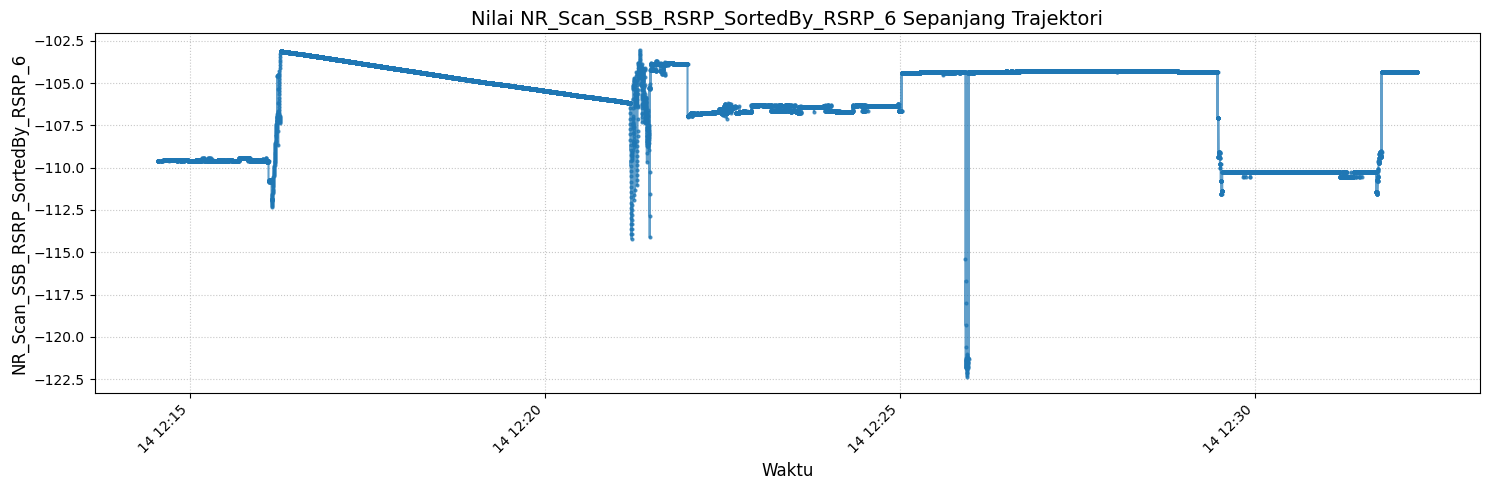

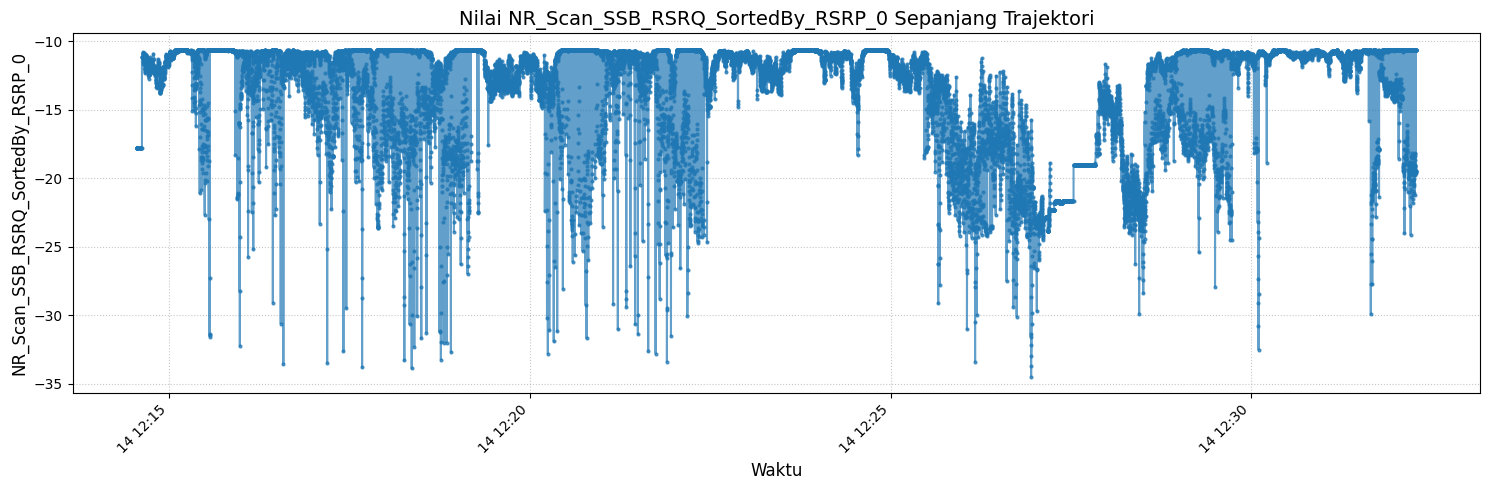

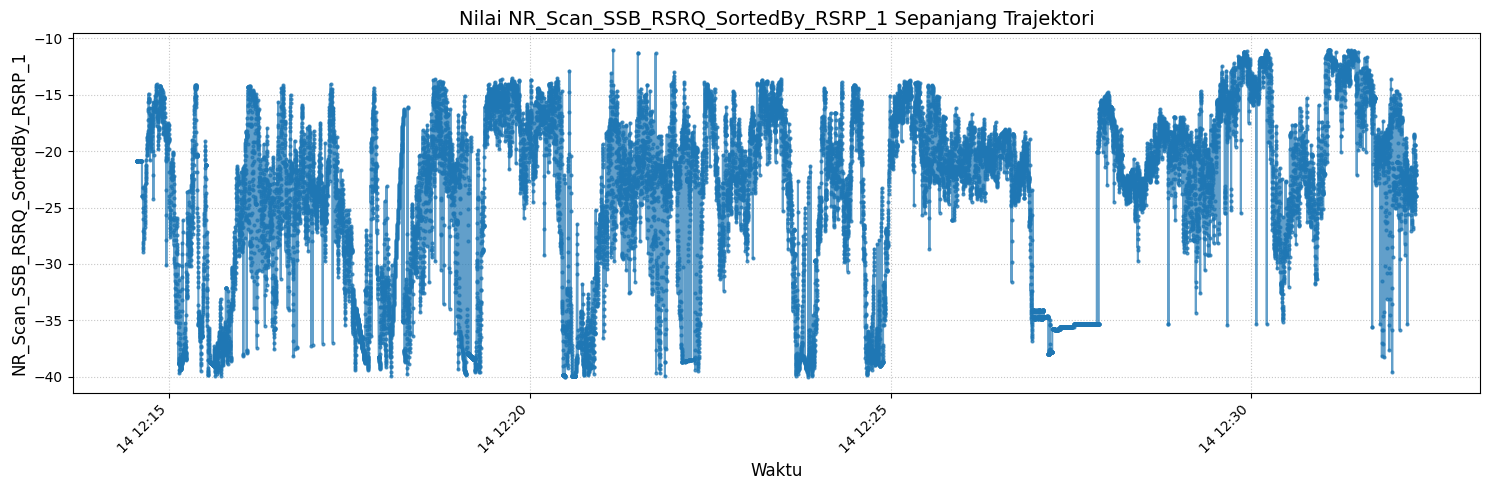

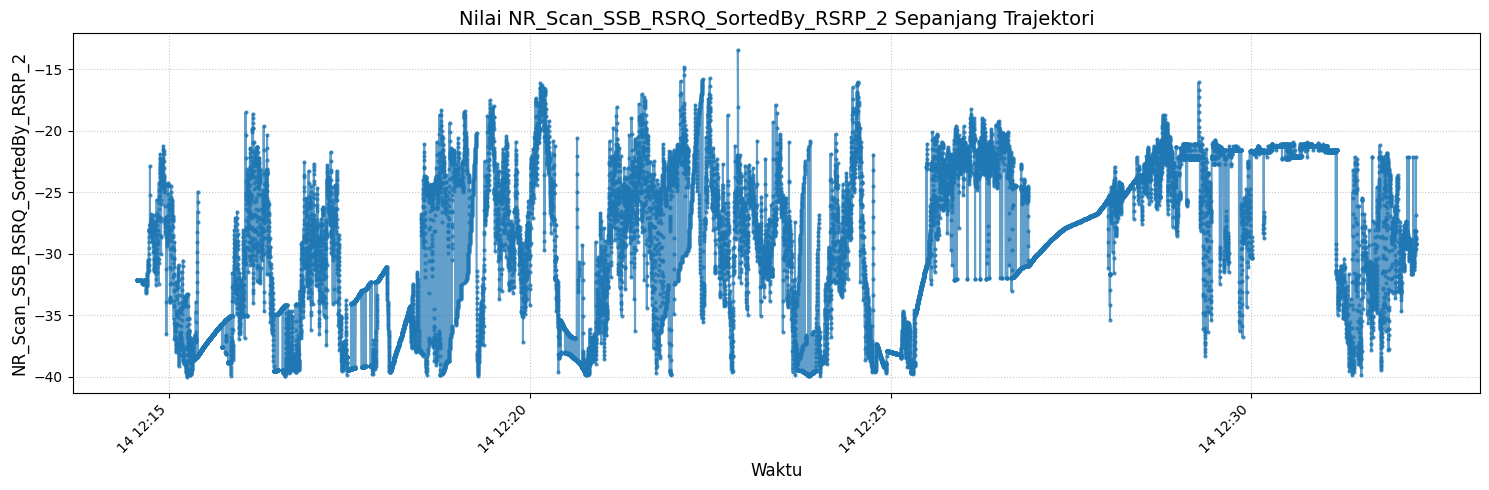

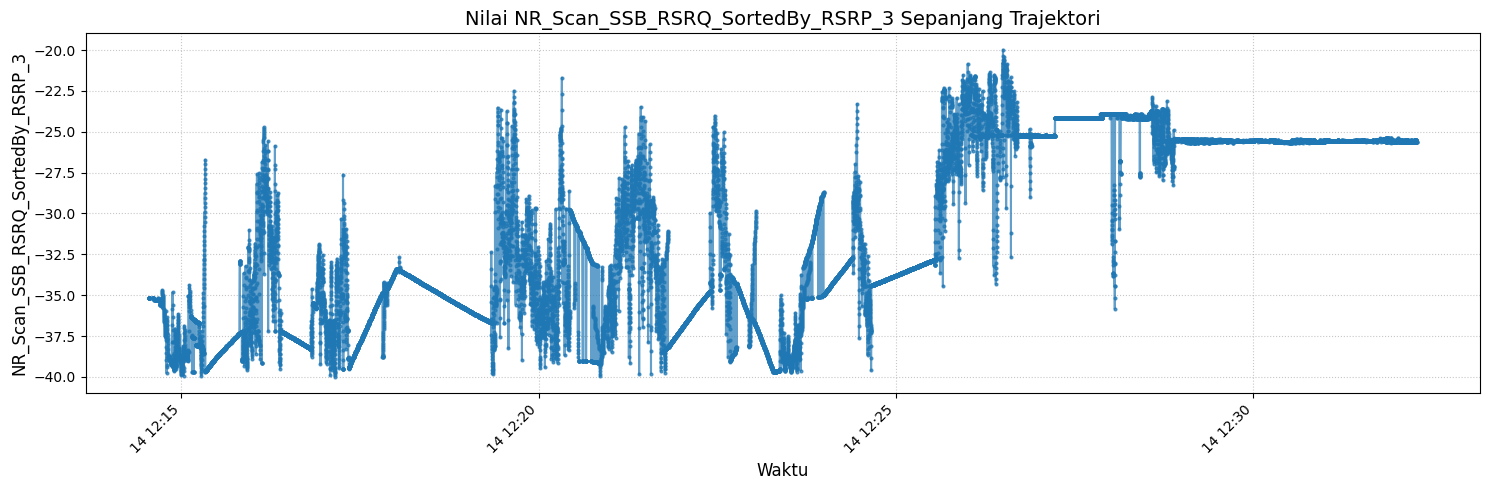

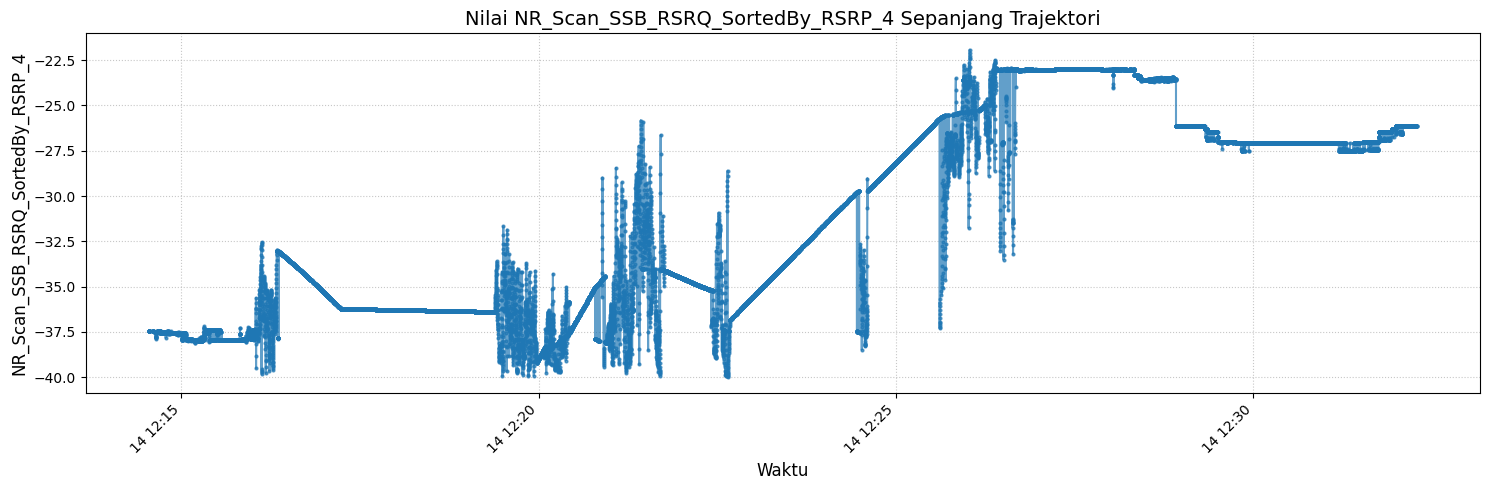

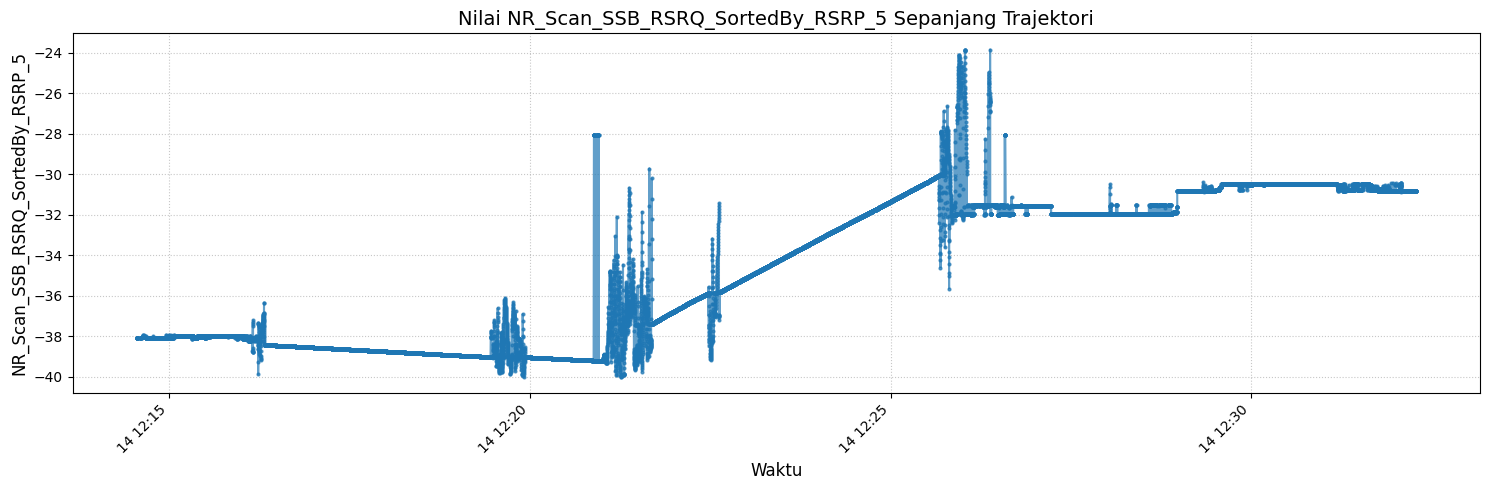

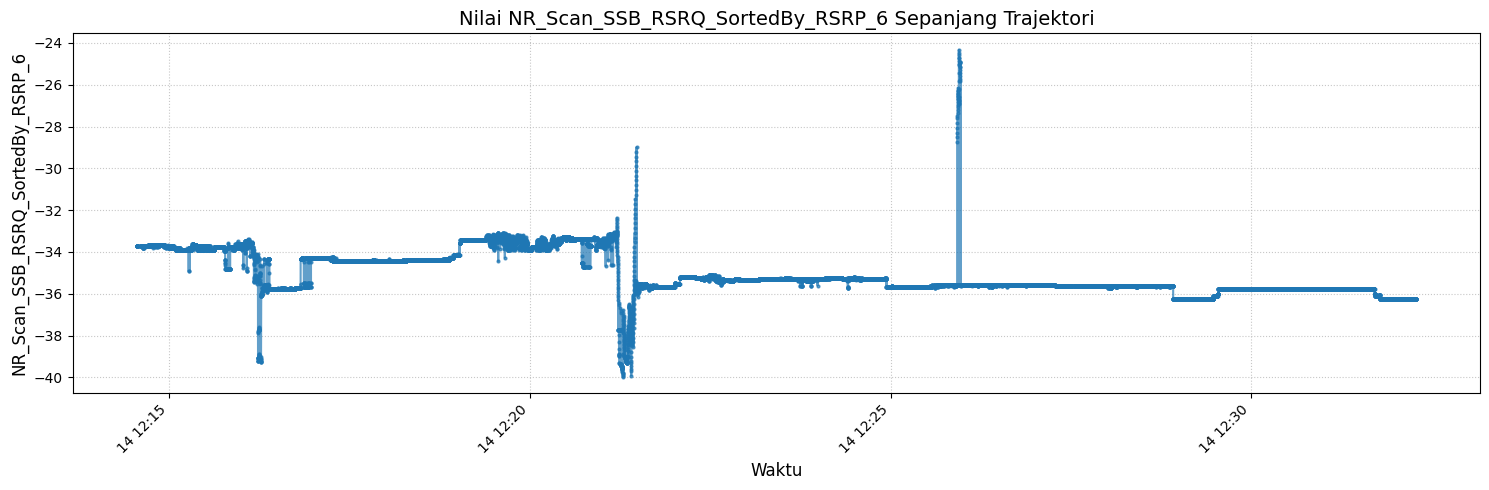

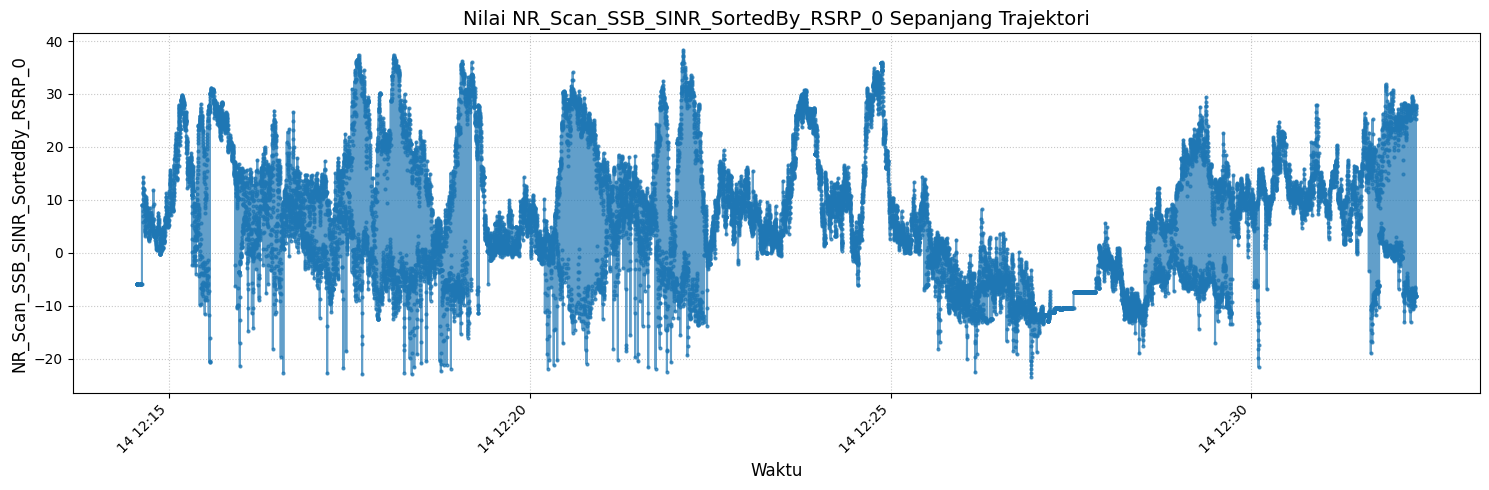

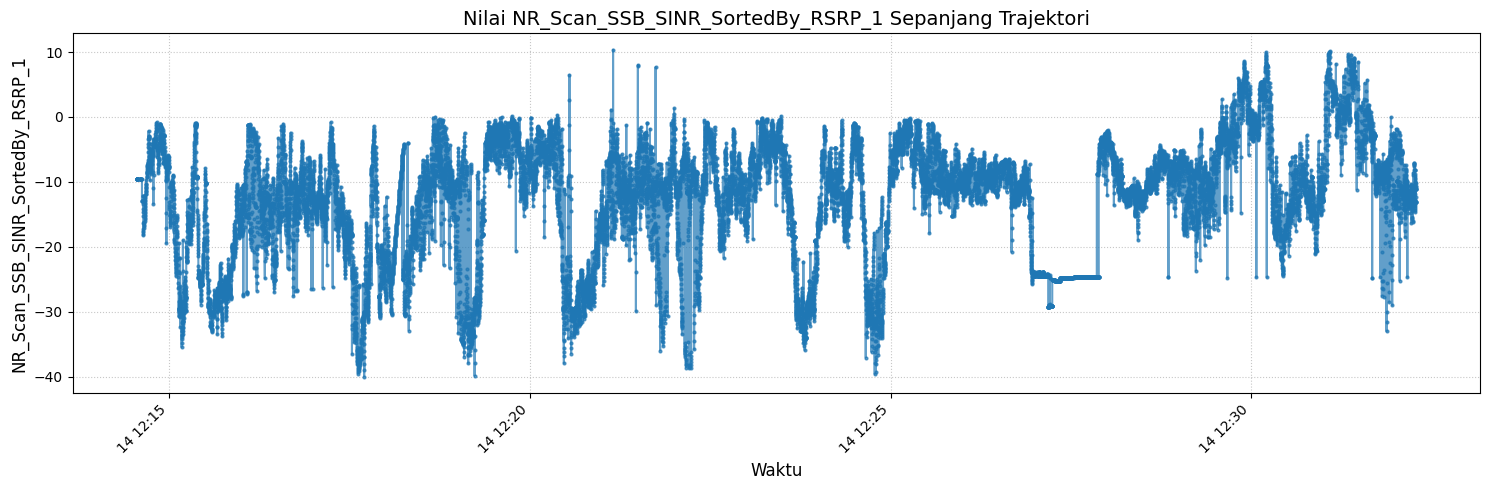

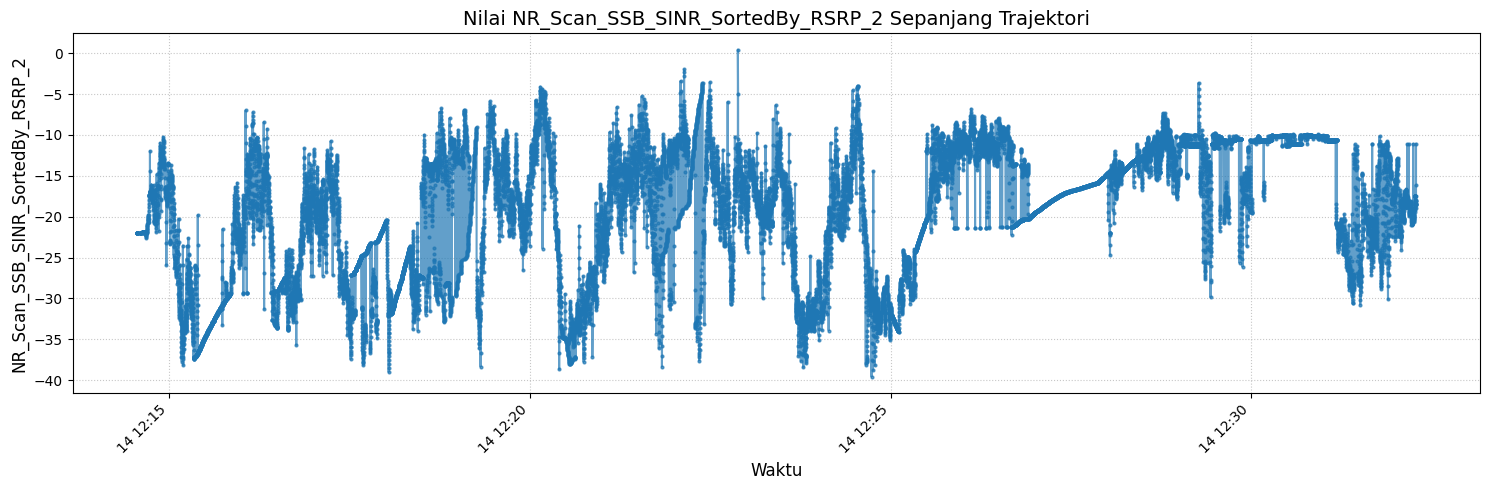

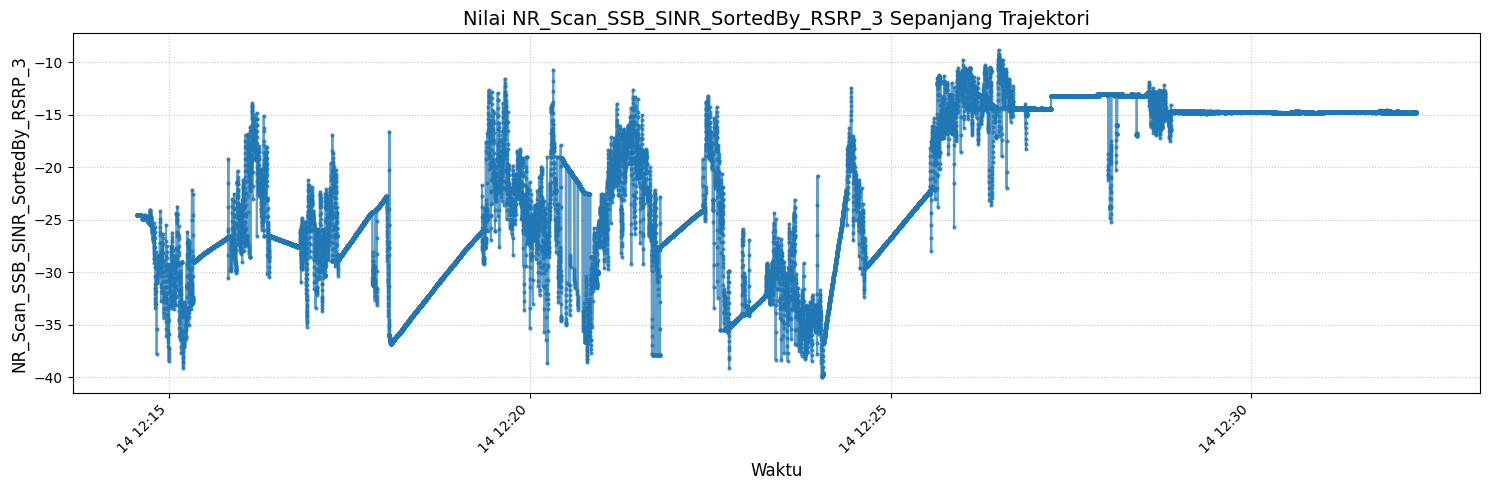

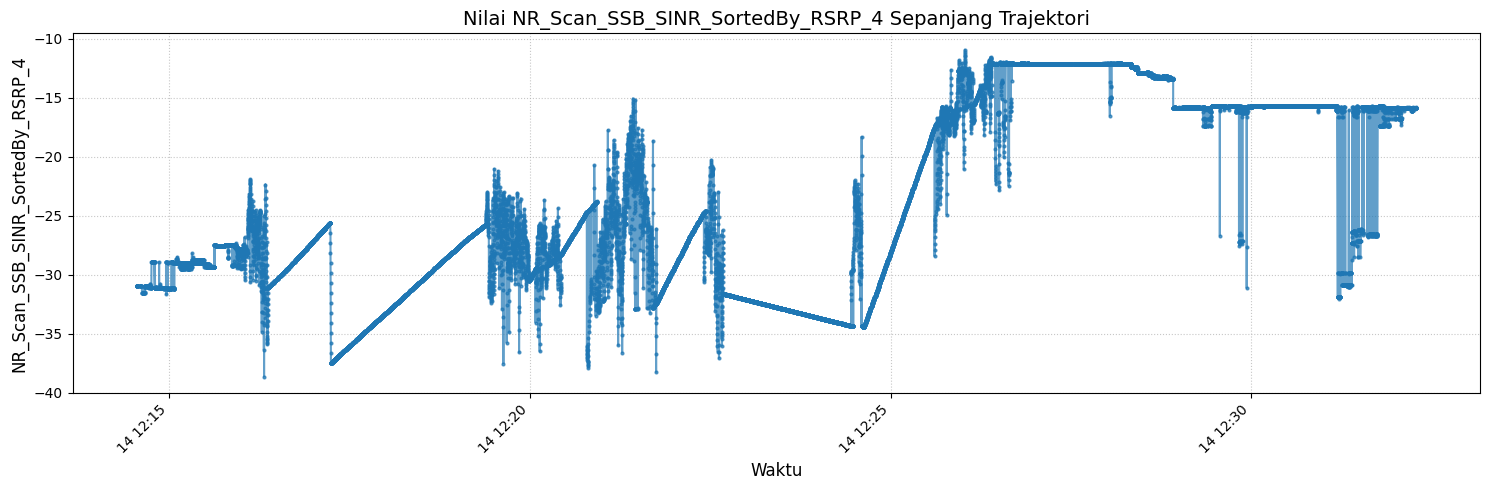

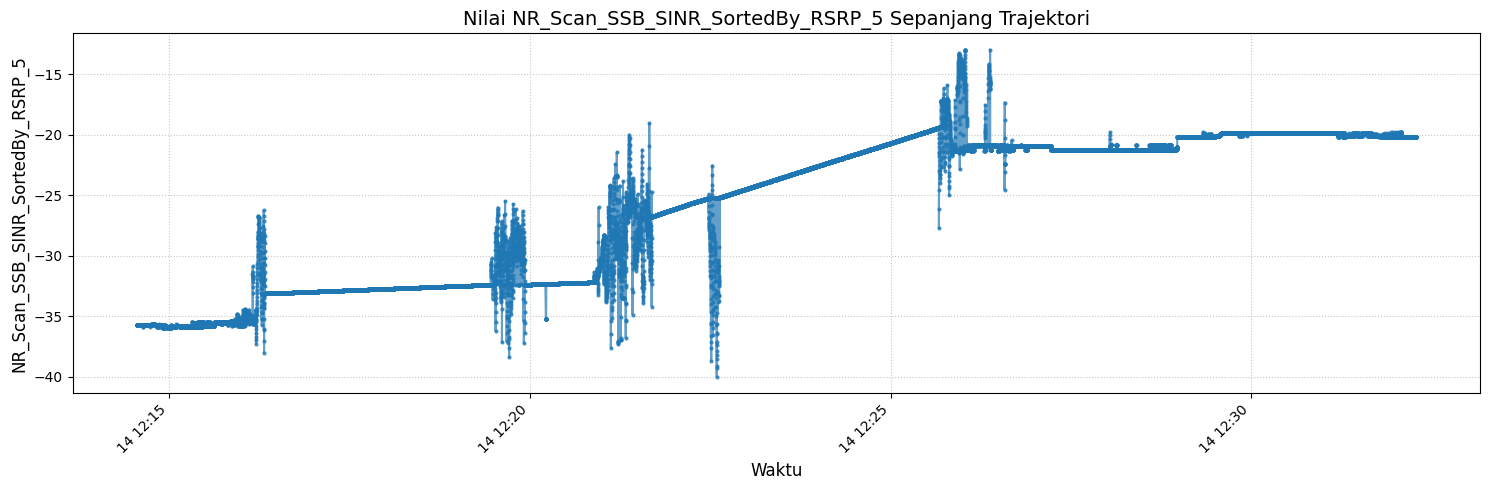

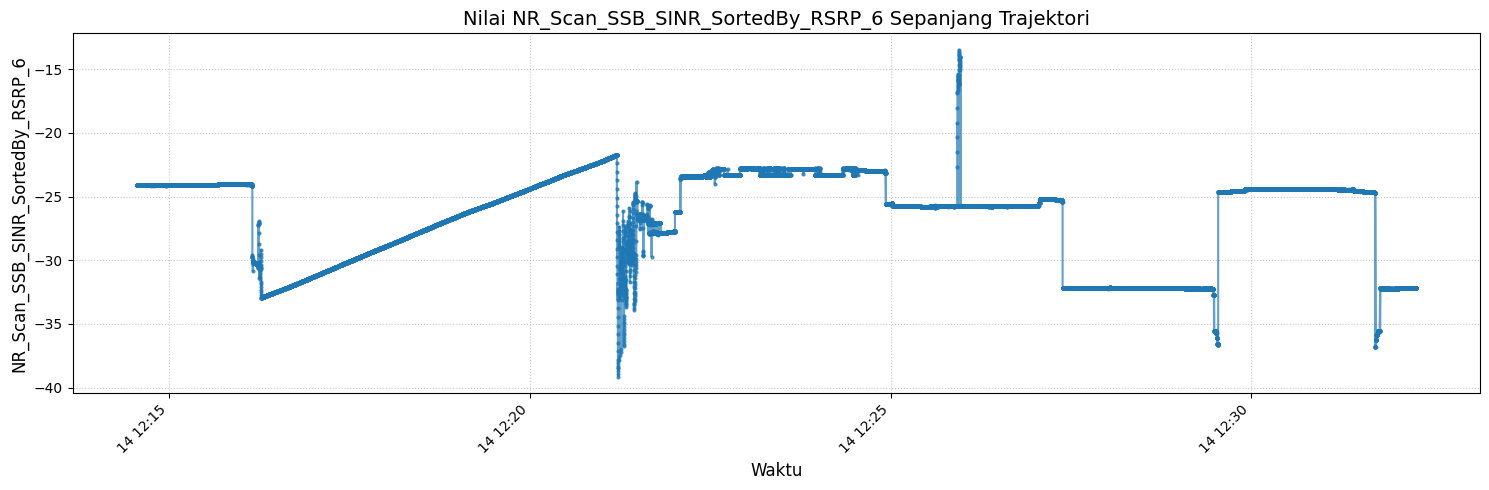

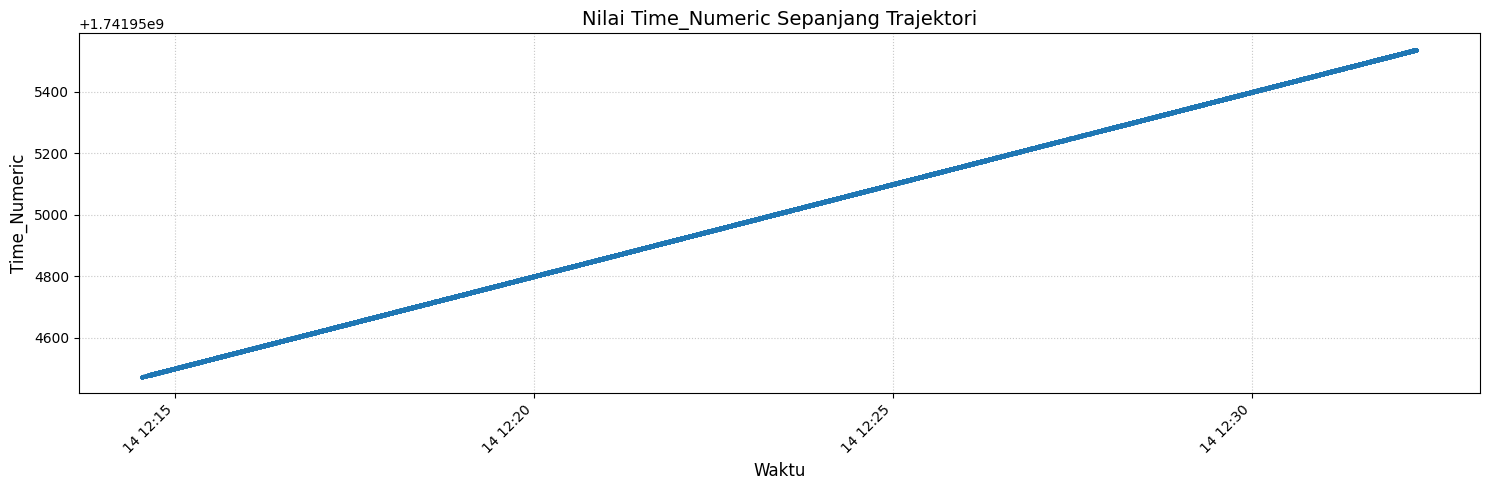


Masukkan nama kolom untuk visualisasi (heatmap & plot vs waktu),
atau ketik 'semua_vs_waktu' untuk plot semua parameter vs waktu,
atau 'selesai' untuk keluar:

--- Skrip Visualisasi Selesai ---


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from scipy.interpolate import griddata
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder
import json
import os
import warnings

# Menonaktifkan beberapa jenis peringatan
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
pd.options.mode.chained_assignment = None

# --- ------------------------------------------------------------------ --- #
# ---               KONFIGURASI UTAMA (SESUAIKAN DI SINI)                --- #
# --- ------------------------------------------------------------------ --- #

DATA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/raw-scanner/Scanner_Fill.xlsx' # <--- GANTI INI!
ANTENNA_FILE_PATH = 'D:/Kuliah-temp/Teknofest/program/dataset/config/antenna.xlsx'

COLUMNS_FOR_LABEL_ENCODING = [
    # 'Technology_Mode',
    # 'NR_UE_Modulation_Avg_DL_0',
    # 'NR_UE_RI_DL_0',
    # 'NR_UE_MCS_DL_0',
    # 'NR_UE_RRCReEst_EndResult',
    # 'NR_RRC_MsgType',
    # 'NAS_5GS_MM_MessageType',
    # 'NAS_5GS_SM_MessageType'



]
NAN_PLACEHOLDER_STRING_FOR_ENCODING = "LE_MISSING"
MAPPING_ENCODING_FILE = 'label_encoding_mappings_v4.json'

MAX_SECTOR_DIAMETER_M = 100
HEATMAP_GRID_DENSITY = 75j
HEATMAP_INTERPOLATION_METHOD = 'linear' # 'linear' lebih cepat & stabil
HEATMAP_COLORMAP = 'plasma'
TRAJECTORY_PLOT_COLOR = 'lightgrey' # Warna garis trajektori
UE_POINTS_COLOR_ON_HEATMAP = 'blue'   # Warna titik UE di atas heatmap
UE_POINTS_ALPHA = 0.5
UE_POINTS_SIZE = 15

TIME_COLUMN_FOR_PLOTS = 'Time'

# --- ------------------------------------------------------------------ --- #
# ---                      AKHIR KONFIGURASI UTAMA                       --- #
# --- ------------------------------------------------------------------ --- #

# --- Fungsi-Fungsi (load_antenna_data, create_antenna_sector_map_points, plot_antennas_on_ax, perform_label_encoding, plot_parameter_over_time_or_index) ---
# (Salin fungsi-fungsi ini dari jawaban sebelumnya, tidak ada perubahan signifikan yang diperlukan untuk fungsi ini)
def load_antenna_data(antenna_file_path):
    try:
        adf = pd.read_excel(antenna_file_path); adf.columns = adf.columns.str.strip()
        adata = adf[adf['Azimuth [°]'].notna()].copy(); tdata = adf[adf['Azimuth [°]'].isna()].copy()
        if 'PCI' not in adata.columns: adata['PCI'] = adata.index
        num_cols = ['Latitude', 'Longitude', 'Azimuth [°]', 'Horizontal Beamwidth [°]', 'PCI']
        for col in num_cols:
            if col in adata.columns: adata[col] = pd.to_numeric(adata[col], errors='coerce')
        return adata.dropna(subset=num_cols), tdata
    except Exception as e: print(f"Error antena: {e}"); return pd.DataFrame(), pd.DataFrame()

def create_antenna_sector_map_points(lat, lon, az, bw, rad_m, n_pts=50):
    m_deg = 111000; r_lon = rad_m/(m_deg*np.cos(np.deg2rad(lat))); r_lat = rad_m/m_deg
    az_rad=np.deg2rad(90-az); bw_rad=np.deg2rad(bw)
    sa=az_rad-bw_rad/2; ea=az_rad+bw_rad/2; ang=np.linspace(sa,ea,n_pts)
    xa=lon+r_lon*np.cos(ang); ya=lat+r_lat*np.sin(ang)
    return np.column_stack((np.concatenate(([lon],xa)), np.concatenate(([lat],ya))))

def plot_antennas_on_ax(ax, adata, tdata, max_diam_m):
    txt_offs=defaultdict(lambda:{'c':0,'a_stp':45,'curr_a':0,'r_f':0.00015}) # Sesuaikan r_f jika teks terlalu jauh/dekat
    tower_label_plotted, antenna_sector_label_plotted, antenna_point_label_plotted = False, False, False
    if not tdata.empty:
        for _, row in tdata.iterrows():
            ax.scatter(row['Longitude'], row['Latitude'], c='black', s=150, 
                       label='Tower Site' if not tower_label_plotted else None, 
                       edgecolor='dimgray', marker='s', zorder=10)
            tower_label_plotted = True
            # Teks untuk tower (opsional)
            # site_key=(round(row['Longitude'],5),round(row['Latitude'],5));oi=txt_offs[site_key]
            # rf=oi['r_f']*(1+oi['c']*0.2);tl=row['Longitude']+rf*np.cos(np.deg2rad(oi['curr_a']));ta=row['Latitude']+rf*np.sin(np.deg2rad(oi['curr_a']))
            # ax.text(tl,ta,f"Site: {row.get('Cell Name', 'N/A')}",fontsize=7,color='k',ha='center',va='center',zorder=12,bbox=dict(fc='w',alpha=0.6,pad=0.1))
            # oi['curr_a']+=oi['a_stp'];oi['c']+=1
            
    if not adata.empty:
        for _, row in adata.iterrows():
            spts=create_antenna_sector_map_points(row['Latitude'],row['Longitude'],row['Azimuth [°]'],row['Horizontal Beamwidth [°]'],max_diam_m/2)
            ax.fill(spts[:,0],spts[:,1],'darkgreen',alpha=0.25,ec='green',lw=0.7,zorder=3,label='Antenna Sector' if not antenna_sector_label_plotted else None)
            antenna_sector_label_plotted = True
            ax.scatter(row['Longitude'],row['Latitude'],c='red',s=60,marker='P',ec='k',zorder=11,label='Antenna Point' if not antenna_point_label_plotted else None)
            antenna_point_label_plotted = True
            sk=(round(row['Longitude'],5),round(row['Latitude'],5));oi=txt_offs[sk]
            rf=oi['r_f']*(1+oi['c']*0.3);tl=row['Longitude']+rf*np.cos(np.deg2rad(oi['curr_a']));ta=row['Latitude']+rf*np.sin(np.deg2rad(oi['curr_a']))
            ax.text(tl,ta,f"PCI:{int(row['PCI'])}",fontsize=7,color='maroon',ha='center',va='center',zorder=12,bbox=dict(fc='w',alpha=0.7,pad=0.1,boxstyle='round,pad=0.1'))
            oi['curr_a']+=oi['a_stp'];oi['c']+=1
    return ax

def perform_label_encoding(df_input, columns_to_encode, nan_placeholder):
    df_encoded = df_input.copy(); mappings = {}
    print("\nMelakukan Label Encoding...")
    for col in columns_to_encode:
        if col not in df_encoded.columns: print(f"  Peringatan: Kolom '{col}' tidak ditemukan. Dilewati."); continue
        print(f"  Encoding kolom: '{col}'")
        series_to_encode = df_encoded[col].fillna(nan_placeholder).astype(str)
        encoder = LabelEncoder()
        df_encoded[col] = encoder.fit_transform(series_to_encode)
        mappings[col] = {cls: code for code, cls in enumerate(encoder.classes_)}
        print(f"    Kolom '{col}' selesai. {len(encoder.classes_)} kelas unik.")
    return df_encoded, mappings

def plot_parameter_over_time_or_index(df_data, param_col, time_col=None, title=""):
    if param_col not in df_data.columns or df_data[param_col].isnull().all():
        print(f"Peringatan: Kolom '{param_col}' tidak ada atau semua NaN. Plot vs waktu/indeks dilewati."); return
    plt.figure(figsize=(15, 5)); x_axis_data, x_label = df_data.index, "Indeks Baris"
    plot_df = df_data.copy() # Bekerja pada salinan untuk plotting
    if time_col and time_col in plot_df.columns:
        if not pd.api.types.is_datetime64_any_dtype(plot_df[time_col]):
            plot_df[time_col] = pd.to_datetime(plot_df[time_col], errors='coerce')
        temp_plot_data = plot_df[[time_col, param_col]].dropna(subset=[time_col])
        if not temp_plot_data.empty: x_axis_data, x_label = temp_plot_data[time_col], "Waktu"
        y_axis_data = temp_plot_data[param_col]
    else: y_axis_data = plot_df[param_col]
    try:
        y_numeric = pd.to_numeric(y_axis_data, errors='coerce')
        plt.plot(x_axis_data, y_numeric, marker='.', linestyle='-', markersize=4, alpha=0.7)
    except Exception: plt.plot(x_axis_data, y_axis_data.astype(str), marker='o', linestyle=' ', markersize=4, alpha=0.7)
    plt.xlabel(x_label, fontsize=12); plt.ylabel(param_col, fontsize=12)
    plt.title(title if title else f"Nilai {param_col} Sepanjang Trajektori", fontsize=14)
    plt.grid(True, linestyle=':', alpha=0.7);
    if x_label == "Waktu": plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show(); plt.close()

# --- Fungsi Plot Utama (Heatmap + Trajektori + Antena) ---
def plot_heatmap_with_trajectory_and_antennas(
    df_display, lon_col, lat_col, value_col_for_heatmap,
    antenna_data, tower_data,
    grid_density=100j, interpolation_method='linear', cmap_heatmap='viridis',
    title_prefix="Plot", max_sector_diam_m=1000, time_col_for_sort=None,
    trajectory_color='lightgrey', ue_points_color='blue', ue_points_alpha=0.5, ue_points_size=15
):
    """
    Membuat plot gabungan: heatmap parameter, trajektori UE (garis dan titik), dan antena.
    """
    if value_col_for_heatmap not in df_display.columns:
        print(f"Error: Kolom '{value_col_for_heatmap}' tidak ada untuk heatmap."); return
    if df_display[value_col_for_heatmap].isnull().all() and pd.api.types.is_numeric_dtype(df_display[value_col_for_heatmap]):
        print(f"Peringatan: Semua nilai di '{value_col_for_heatmap}' (numerik) adalah NaN. Heatmap tidak dibuat.");
        # Tetap lanjutkan untuk plot trajektori dan antena
    elif not pd.api.types.is_numeric_dtype(df_display[value_col_for_heatmap]):
         print(f"Peringatan: Kolom '{value_col_for_heatmap}' bukan numerik. Heatmap nilai tidak dibuat. Hanya trajektori & antena.")


    print(f"\nMembuat plot gabungan untuk: {value_col_for_heatmap}...")
    fig, ax = plt.subplots(figsize=(18, 14))

    # 1. Heatmap (hanya jika value_col_for_heatmap adalah numerik dan punya data valid)
    can_create_heatmap = False
    if pd.api.types.is_numeric_dtype(df_display[value_col_for_heatmap]) and not df_display[value_col_for_heatmap].isnull().all():
        heatmap_data = df_display[[lon_col, lat_col, value_col_for_heatmap]].dropna()
        if not heatmap_data.empty:
            points = heatmap_data[[lon_col, lat_col]].values
            values = heatmap_data[value_col_for_heatmap].values
            
            grid_x_min, grid_x_max = heatmap_data[lon_col].min(), heatmap_data[lon_col].max()
            grid_y_min, grid_y_max = heatmap_data[lat_col].min(), heatmap_data[lat_col].max()
            buffer_x = (grid_x_max-grid_x_min)*0.05 or 0.001; buffer_y = (grid_y_max-grid_y_min)*0.05 or 0.001
            grid_x, grid_y = np.mgrid[grid_x_min-buffer_x:grid_x_max+buffer_x:grid_density, 
                                      grid_y_min-buffer_y:grid_y_max+buffer_y:grid_density]
            
            unique_pts = np.unique(points,axis=0)
            current_interp = interpolation_method
            if len(unique_pts) < 4 and current_interp == 'cubic': current_interp = 'linear'
            if len(unique_pts) < 2 and current_interp == 'linear': current_interp = 'nearest'

            try:
                grid_z = griddata(points, values, (grid_x, grid_y), method=current_interp, fill_value=np.nan)
                valid_v_scale = values[~np.isnan(values)]
                vmin=np.percentile(valid_v_scale,2) if len(valid_v_scale)>0 else None
                vmax=np.percentile(valid_v_scale,98) if len(valid_v_scale)>0 else None
                if vmin is not None and vmin==vmax: vmin=vmin-0.5 if vmin!=0 else -0.5; vmax=vmax+0.5 if vmax!=0 else 0.5
                
                im = ax.imshow(grid_z.T, extent=(grid_x.min(),grid_x.max(),grid_y.min(),grid_y.max()),
                               origin='lower', cmap=cmap_heatmap, aspect='auto', alpha=0.7, zorder=0,
                               norm=Normalize(vmin=vmin,vmax=vmax) if vmin is not None else None)
                cbar = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.05, aspect=30)
                cbar.set_label(value_col_for_heatmap, fontsize=10)
                can_create_heatmap = True
            except Exception as e: print(f"  Gagal membuat heatmap untuk '{value_col_for_heatmap}': {e}")
        else: print(f"  Tidak ada data valid untuk heatmap '{value_col_for_heatmap}'.")
    
    # 2. Plot Trajektori UE
    df_plot_traj = df_display.copy()
    if time_col_for_sort and time_col_for_sort in df_plot_traj.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_plot_traj[time_col_for_sort]):
            df_plot_traj[time_col_for_sort] = pd.to_datetime(df_plot_traj[time_col_for_sort], errors='coerce')
        df_plot_traj.sort_values(by=time_col_for_sort, inplace=True, na_position='first')
    
    # Plot garis trajektori
    ax.plot(df_plot_traj[lon_col], df_plot_traj[lat_col], 
            color=trajectory_color, linestyle='-', linewidth=1.5, alpha=0.8, 
            label='Trajektori UE', zorder=1)
    
    # Plot titik-titik pengukuran UE
    # Jika heatmap dibuat dan kolomnya numerik, warnai titik UE berdasarkan nilainya
    # Jika tidak, gunakan warna default
    if can_create_heatmap and pd.api.types.is_numeric_dtype(df_plot_traj[value_col_for_heatmap]):
        scatter_colors = df_plot_traj[value_col_for_heatmap]
        scatter_cmap = cmap_heatmap
        # Gunakan vmin/vmax yang sama dengan heatmap untuk konsistensi skala warna
        scatter_norm = Normalize(vmin=vmin if 'vmin' in locals() and vmin is not None else scatter_colors.min(),
                                 vmax=vmax if 'vmax' in locals() and vmax is not None else scatter_colors.max())
    else:
        scatter_colors = ue_points_color
        scatter_cmap = None
        scatter_norm = None

    ax.scatter(df_plot_traj[lon_col], df_plot_traj[lat_col], 
               c=scatter_colors, cmap=scatter_cmap, norm=scatter_norm,
               edgecolor='black', linewidth=0.3, s=ue_points_size, alpha=ue_points_alpha, 
               label='Titik Pengukuran UE', zorder=2)

    # 3. Plot Antena
    ax = plot_antennas_on_ax(ax, antenna_data, tower_data, max_sector_diam_m)

    # Kustomisasi
    ax.set_title(f"{title_prefix}: {value_col_for_heatmap}", fontsize=14)
    ax.set_xlabel("Longitude", fontsize=10); ax.set_ylabel("Latitude", fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=-1)
    
    handles, labels = ax.get_legend_handles_labels()
    by_label = {lbl: hnd for hnd, lbl in zip(handles, labels) if lbl is not None} # Filter None labels
    if by_label: ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=8)
    
    # Atur batas plot agar semua terlihat
    all_lons = pd.concat([df_display[lon_col], antenna_data['Longitude'] if not antenna_data.empty else pd.Series(dtype=float)])
    all_lats = pd.concat([df_display[lat_col], antenna_data['Latitude'] if not antenna_data.empty else pd.Series(dtype=float)])
    if not all_lons.empty and not all_lats.empty:
        plot_buffer = 0.002 # Buffer untuk batas plot
        ax.set_xlim(all_lons.min() - plot_buffer, all_lons.max() + plot_buffer)
        ax.set_ylim(all_lats.min() - plot_buffer, all_lats.max() + plot_buffer)

    ax.set_aspect('equal', adjustable='box')
    plt.tight_layout(); plt.show(); plt.close(fig)


if __name__ == '__main__':
    # 1. Muat Data Utama
    print(f"Memuat data utama dari: {DATA_FILE_PATH}")
    try:
        if DATA_FILE_PATH.endswith('.xlsx'):
            df_main = pd.read_excel(DATA_FILE_PATH, sheet_name="Series_Formatted_Data") # Tambahkan sheet_name jika perlu
        elif DATA_FILE_PATH.endswith('.csv'):
            df_main = pd.read_csv(DATA_FILE_PATH, low_memory=False)
        else: print("Format file data utama tidak didukung."); exit()
        df_main.columns = df_main.columns.str.strip()
        print(f"Data utama dimuat: {len(df_main)} baris.")
    except FileNotFoundError: print(f"FATAL: File data utama '{DATA_FILE_PATH}' tidak ditemukan."); exit()
    except Exception as e: print(f"FATAL: Error membaca data utama: {e}"); exit()
    if df_main.empty: print("FATAL: Data utama kosong."); exit()

    # Urutkan berdasarkan waktu jika ada, untuk konsistensi trajektori
    if TIME_COLUMN_FOR_PLOTS and TIME_COLUMN_FOR_PLOTS in df_main.columns:
        if not pd.api.types.is_datetime64_any_dtype(df_main[TIME_COLUMN_FOR_PLOTS]):
            try: df_main[TIME_COLUMN_FOR_PLOTS] = pd.to_datetime(df_main[TIME_COLUMN_FOR_PLOTS], errors='coerce')
            except Exception as e_time: print(f"Peringatan: Gagal konversi kolom waktu '{TIME_COLUMN_FOR_PLOTS}': {e_time}")
        if TIME_COLUMN_FOR_PLOTS in df_main.columns and pd.api.types.is_datetime64_any_dtype(df_main[TIME_COLUMN_FOR_PLOTS]):
            df_main.sort_values(by=TIME_COLUMN_FOR_PLOTS, inplace=True, na_position='first')
    df_main.reset_index(drop=True, inplace=True)


    # 2. Muat Data Antena
    antenna_data_global, tower_data_global = load_antenna_data(ANTENNA_FILE_PATH)

    # 3. Label Encoding untuk kolom string yang ditentukan
    df_processed_for_plot = df_main.copy()
    mappings_dict = {}
    if COLUMNS_FOR_LABEL_ENCODING:
        df_processed_for_plot, mappings_dict = perform_label_encoding(
            df_processed_for_plot,
            COLUMNS_FOR_LABEL_ENCODING,
            NAN_PLACEHOLDER_STRING_FOR_ENCODING
        )
        try: # Simpan mapping
            output_dir_map = os.path.dirname(MAPPING_ENCODING_FILE)
            if output_dir_map and not os.path.exists(output_dir_map): os.makedirs(output_dir_map)
            with open(MAPPING_ENCODING_FILE, 'w') as f: json.dump(mappings_dict, f, indent=4)
            print(f"Mapping Label Encoding disimpan ke: {MAPPING_ENCODING_FILE}")
        except Exception as e: print(f"Gagal menyimpan mapping: {e}")
    
    # 4. Tampilkan Pilihan Kolom & Plot
    print("\nKolom yang tersedia untuk visualisasi (prioritaskan numerik/encoded):")
    # Pilih kolom yang numerik atau hasil dari label encoding (yang juga jadi numerik)
    plottable_cols = []
    for col in df_processed_for_plot.columns:
        if col not in ['Latitude', 'Longitude', TIME_COLUMN_FOR_PLOTS]:
            if pd.api.types.is_numeric_dtype(df_processed_for_plot[col]):
                 if df_processed_for_plot[col].nunique(dropna=True) > 1: # Hanya jika ada variasi
                    plottable_cols.append(col)
                    print(f" - {col} (Numerik, Unik: {df_processed_for_plot[col].nunique()})")
            elif col in mappings_dict: # Hasil Label Encoding juga numerik
                if df_processed_for_plot[col].nunique(dropna=True) > 1:
                    plottable_cols.append(col)
                    print(f" - {col} (Hasil Encode, Unik: {df_processed_for_plot[col].nunique()})")
    
    if not plottable_cols: print("Tidak ada kolom yang cocok untuk diplot. Periksa data."); exit()

    while True:
        print("\nMasukkan nama kolom untuk visualisasi (heatmap & plot vs waktu),")
        print("atau ketik 'semua_vs_waktu' untuk plot semua parameter vs waktu,")
        print("atau 'selesai' untuk keluar:")
        selected_input = input("> ").strip()

        if selected_input.lower() == 'selesai': break
        
        else:
            print("\nMemplot semua parameter numerik/encoded yang valid terhadap waktu/indeks...")
            for plot_col_name in plottable_cols:
                plot_parameter_over_time_or_index(
                    df_data=df_processed_for_plot,
                    param_col=plot_col_name,
                    time_col=TIME_COLUMN_FOR_PLOTS
                )
            continue

        if selected_input in plottable_cols:
            # Plot Gabungan Heatmap, Trajektori, dan Antena
            plot_heatmap_with_trajectory_and_antennas(
                df_display=df_processed_for_plot,
                lon_col='Longitude', lat_col='Latitude',
                value_col_for_heatmap=selected_input,
                antenna_data=antenna_data_global, tower_data=tower_data_global,
                grid_density=HEATMAP_GRID_DENSITY,
                interpolation_method=HEATMAP_INTERPOLATION_METHOD,
                cmap_heatmap=HEATMAP_COLORMAP,
                title_prefix="Visualisasi Spasial",
                max_sector_diam_m=MAX_SECTOR_DIAMETER_M,
                time_col_for_sort=TIME_COLUMN_FOR_PLOTS,
                trajectory_color=TRAJECTORY_PLOT_COLOR,
                ue_points_color=UE_POINTS_COLOR_ON_HEATMAP,
                ue_points_alpha=UE_POINTS_ALPHA,
                ue_points_size=UE_POINTS_SIZE
            )
            # Plot Parameter vs Waktu/Indeks (untuk kolom yang sama)
            plot_parameter_over_time_or_index(
                df_data=df_processed_for_plot,
                param_col=selected_input,
                time_col=TIME_COLUMN_FOR_PLOTS
            )
        else:
            print(f"Nama kolom '{selected_input}' tidak valid. Silakan coba lagi.")

    print("\n--- Skrip Visualisasi Selesai ---")